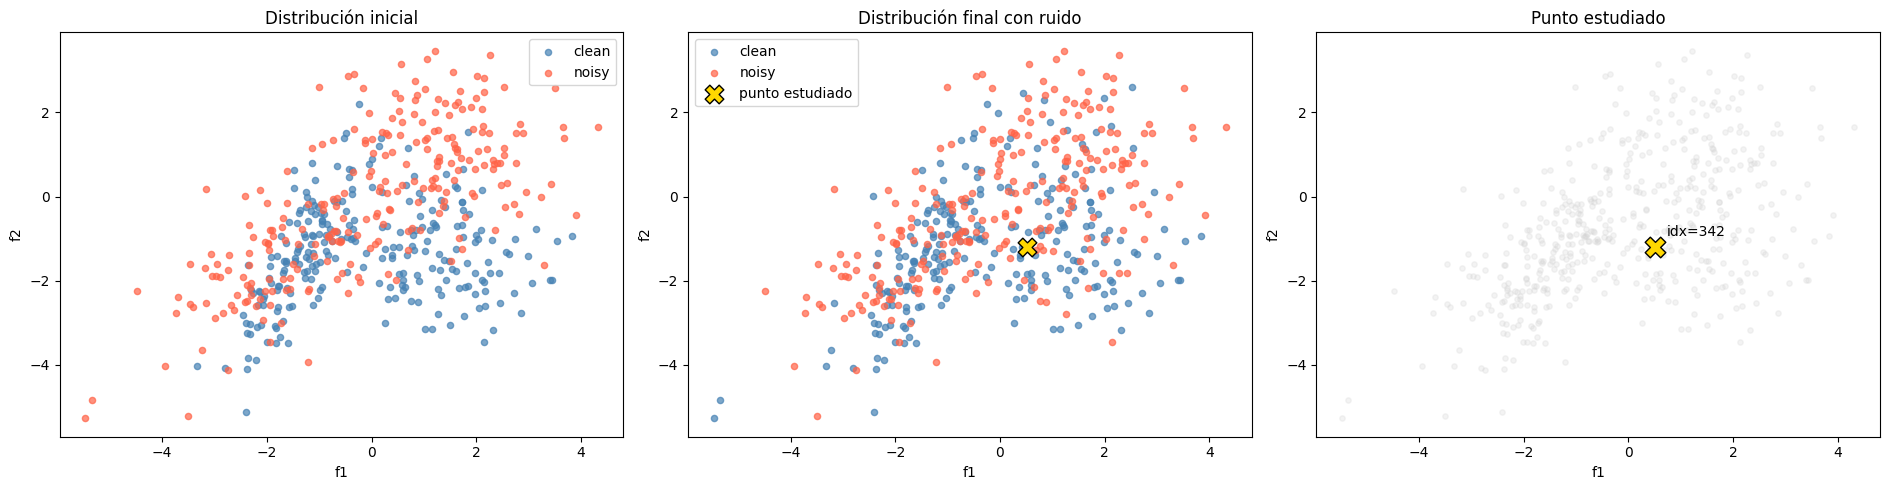

Índice estudiado: 342
Etiqueta observada: noisy
Etiqueta predicha: noisy
Explanatory noise score: 0.0

Top features:
  feature     value  phi_observed  phi_predicted  delta_phi  abs_delta_phi  \
0     f10  2.026383      0.050682       0.050682        0.0            0.0   
1      f9  0.857331      0.022782       0.022782        0.0            0.0   
2      f8  2.559525      0.168595       0.168595        0.0            0.0   
3      f7 -1.441844      0.036188       0.036188        0.0            0.0   
4      f6 -1.131737     -0.003323      -0.003323        0.0            0.0   

  direction                                     interpretation  
0   neutral  Favorece ambas clases, pero mas intensamente l...  
1   neutral  Favorece ambas clases, pero mas intensamente l...  
2   neutral  Favorece ambas clases, pero mas intensamente l...  
3   neutral  Favorece ambas clases, pero mas intensamente l...  
4   neutral  Penaliza ambas clases, pero con distinta inten...  

Diferencia SHAP por fea

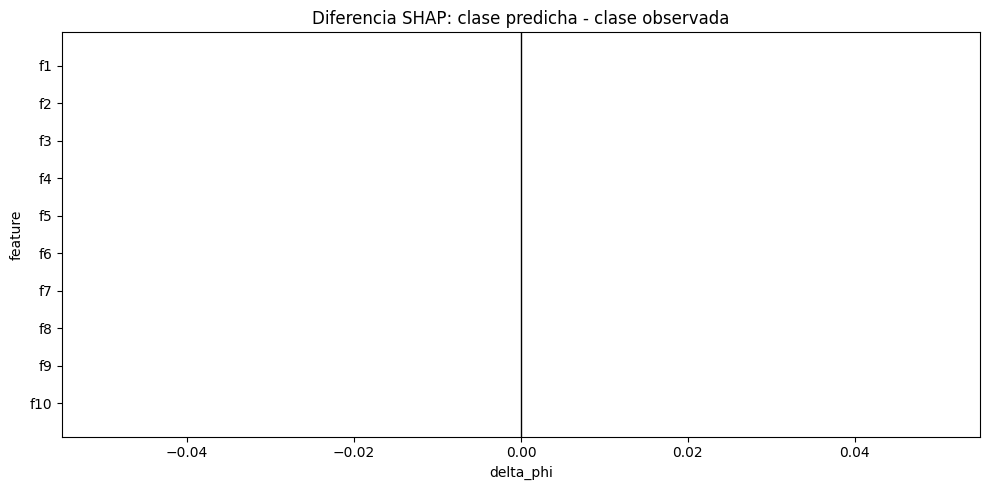

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

from filters import explain_instance_shap_difference, explain_noisy_instances_with_shap

# -----------------------------
# 1) Dataset sintético 10D
# -----------------------------
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=4,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=1.3,
    flip_y=0,
    random_state=42,
)

feature_names = [f"f{i+1}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

# Etiquetas originales
y = pd.Series(y).map({0: "clean", 1: "noisy"}).to_numpy()

# -----------------------------
# 2) Añadir ruido a etiquetas
# -----------------------------
rng = np.random.default_rng(42)
noise_fraction = 0.12
n_noisy = int(len(y) * noise_fraction)
noisy_idx = rng.choice(len(y), size=n_noisy, replace=False)

y_noisy = y.copy()
y_noisy[noisy_idx] = np.where(y_noisy[noisy_idx] == "clean", "noisy", "clean")
noisy_mask = y != y_noisy

# Punto ruidoso a estudiar
target_idx = int(noisy_idx[0])

# -----------------------------
# 3) Gráficos de distribución
# -----------------------------
# Para visualizar 10D en 2D usamos las dos primeras dimensiones
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Distribución inicial
axes[0].scatter(
    X.loc[y == "clean", "f1"],
    X.loc[y == "clean", "f2"],
    c="steelblue",
    alpha=0.7,
    s=20,
    label="clean",
)
axes[0].scatter(
    X.loc[y == "noisy", "f1"],
    X.loc[y == "noisy", "f2"],
    c="tomato",
    alpha=0.7,
    s=20,
    label="noisy",
)
axes[0].set_title("Distribución inicial")
axes[0].set_xlabel("f1")
axes[0].set_ylabel("f2")
axes[0].legend()

# Distribución final con ruido
axes[1].scatter(
    X.loc[y_noisy == "clean", "f1"],
    X.loc[y_noisy == "clean", "f2"],
    c="steelblue",
    alpha=0.7,
    s=20,
    label="clean",
)
axes[1].scatter(
    X.loc[y_noisy == "noisy", "f1"],
    X.loc[y_noisy == "noisy", "f2"],
    c="tomato",
    alpha=0.7,
    s=20,
    label="noisy",
)
axes[1].scatter(
    X.loc[target_idx, "f1"],
    X.loc[target_idx, "f2"],
    c="gold",
    s=180,
    marker="X",
    edgecolor="black",
    label="punto estudiado",
)
axes[1].set_title("Distribución final con ruido")
axes[1].set_xlabel("f1")
axes[1].set_ylabel("f2")
axes[1].legend()

# Zoom del punto estudiado
axes[2].scatter(
    X.loc[y_noisy == "clean", "f1"],
    X.loc[y_noisy == "clean", "f2"],
    c="lightgray",
    alpha=0.25,
    s=15,
)
axes[2].scatter(
    X.loc[y_noisy == "noisy", "f1"],
    X.loc[y_noisy == "noisy", "f2"],
    c="lightgray",
    alpha=0.25,
    s=15,
)
axes[2].scatter(
    X.loc[target_idx, "f1"],
    X.loc[target_idx, "f2"],
    c="gold",
    s=220,
    marker="X",
    edgecolor="black",
)
axes[2].annotate(
    f"idx={target_idx}",
    (X.loc[target_idx, "f1"], X.loc[target_idx, "f2"]),
    textcoords="offset points",
    xytext=(8, 8),
)
axes[2].set_title("Punto estudiado")
axes[2].set_xlabel("f1")
axes[2].set_ylabel("f2")

plt.tight_layout()
plt.show()

# -----------------------------
# 4) Entrenar modelo
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_noisy, test_size=0.3, random_state=42, stratify=y_noisy
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
)
model.fit(X_train, y_train)

# -----------------------------
# 5) SHAP values
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

class_labels = np.array(model.classes_, dtype=object)

if isinstance(shap_values, list):
    shap_values_all = np.stack(shap_values, axis=1)  # (n_samples, n_classes, n_features)
else:
    shap_values_all = np.asarray(shap_values)

y_pred = model.predict(X)

# -----------------------------
# 6) Explicar el punto ruidoso
# -----------------------------
report = explain_noisy_instances_with_shap(
    X=X,
    y_observed=y_noisy,
    y_pred=y_pred,
    shap_values_all=shap_values_all,
    class_labels=class_labels,
    feature_names=feature_names,
    noisy_mask=noisy_mask,
    top_k=5,
)

item = next(r for r in report if r.instance_index == target_idx)

print("Índice estudiado:", item.instance_index)
print("Etiqueta observada:", item.observed_label)
print("Etiqueta predicha:", item.predicted_label)
print("Explanatory noise score:", item.explanatory_noise_score)
print("\nTop features:")
print(item.top_features)

# Explicación detallada de diferencias SHAP entre clases
diff_df = explain_instance_shap_difference(
    shap_values=shap_values_all[target_idx],
    class_labels=class_labels,
    feature_names=feature_names,
    feature_values=X.iloc[target_idx].to_numpy(),
    observed_label=item.observed_label,
    predicted_label=item.predicted_label,
    top_k=10,
)

print("\nDiferencia SHAP por feature:")
print(diff_df)

# -----------------------------
# 7) Gráfico SHAP de diferencia
# -----------------------------
plt.figure(figsize=(10, 5))
top_plot = diff_df.sort_values("abs_delta_phi", ascending=True)
colors = ["tomato" if v > 0 else "steelblue" for v in top_plot["delta_phi"]]

plt.barh(top_plot["feature"], top_plot["delta_phi"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Diferencia SHAP: clase predicha - clase observada")
plt.xlabel("delta_phi")
plt.ylabel("feature")
plt.tight_layout()
plt.show()